# Image identification using a CNN

**Taken From:** https://www.tensorflow.org/tutorials/images/cnn<br>

In [76]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

### Import TensorFlow

In [77]:
import tensorflow as tf
import numpy as np

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# eliminate deprecation warnings
import tensorflow.python.util.deprecation as deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False

In [78]:
model = tf.keras.models.load_model('cifar10-cnn-10.1')

In [79]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32, 32, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 30, 30, 32)        9248      
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 30, 30, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 14, 14, 32)        9248      
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 14, 14, 32)        0         
                                                                 
 conv2d_3 (Conv2D)           (None, 12, 12, 64)        1

In [80]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [81]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_sample(sample):
    #layer_outputs = [layer.output for layer in model.layers[:4]]
    layer_outputs = [layer.output for layer in model.layers[0:6:2]]
    layer_outputs.append(model.layers[9].output) 
    
    activation_model = tf.keras.Model(inputs=model.input, outputs=layer_outputs)
    activations = activation_model.predict(sample)
    
    layer_names = []
    for layer in model.layers[:]:
        layer_names.append(layer.name) # Names of the layers, so you can have them as part of your plot
    
    images_per_row = 16
    for layer_name, layer_activation in zip(layer_names, activations):
        # Displays the feature maps
        n_features = layer_activation.shape[-1] # Number of features in the feature map
        size = layer_activation.shape[1] # The feature map has shape (1, size, size, n_features).
        n_cols = n_features // images_per_row # Tiles the activation channels in this matrix
        display_grid = np.zeros((size * n_cols, images_per_row * size))
        for col in range(n_cols): # Tiles each filter into a big horizontal grid
            for row in range(images_per_row):
                channel_image = layer_activation[0, :, :, col * images_per_row + row]
                channel_image -= channel_image.mean() # Post-processes the feature to make it visually palatable
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
                channel_image = np.clip(channel_image, 0, 255).astype('uint8')
                display_grid[col * size: (col + 1) * size, # Displays the grid
                             row * size: (row + 1) * size] = channel_image
        scale = 1. / size
        plt.figure(figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0]))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')
        plt.show()

In [82]:
import cv2
def display_heatmap_pred(target_img, input_img, layer_idx, act):
    # make a list of the layers we care about
    layer_outputs = [layer.output for layer in model.layers[0:6:2]]
    layer_outputs = layer_outputs + [model.layers[9].output]

    # create a custom model that outputs the value of those layers
    activations_model = tf.keras.Model(inputs=model.input, 
                                      outputs=layer_outputs)

    # predict on passed image to fill those layers for drawing activations
    activations = activations_model.predict(input_img)
    
    final_layer_activations = activations[layer_idx]
    
    img = cv2.imread(target_img)
    
    heatmap = final_layer_activations[0, :, :, act]
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * 0.4 + img
    cv2.imwrite("heatmap.jpg", superimposed_img)
    
    result = imageio.imread('heatmap.jpg')
    plt.imshow(result)

In [83]:
import imageio.v2 as imageio
from skimage.transform import resize

import ipywidgets as widgets

output = widgets.Output()
@output.capture()
def predict_image(sender):
    #if file were png, we'd need toconvert to jpg to get rid of alpha
    # jpg conversion can be done with PILLOW Library (not shown here)
    filename = input_text.value + '.jpg'
    input_text.value = ''
    img = imageio.imread(filename)
    img = resize(img, (32,32))
    plt.imshow(img)
    plt.show() #needed to send to output capture
    print(img.shape)
    
    test = np.expand_dims(img, axis=0)
    pred = model.predict(test)[0]
    visualize_sample(test)
    display_heatmap_pred(filename, test, 2, 0)
    
    idx = pred.argmax()
    print(class_names[idx])

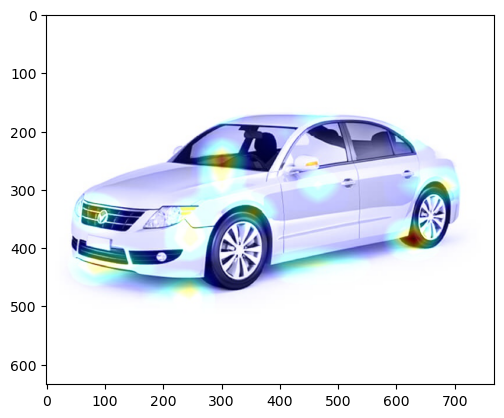

In [84]:
input_text = widgets.Text()
submit = widgets.Button(description='Submit')
submit.on_click(predict_image)
widgets.VBox([widgets.HBox([input_text, submit]), output])